missing values before preprocessing
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

missing values after cleaning
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


C:\Users\abnvz\AppData\Local\Temp\ipykernel_5600\4180954167.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')


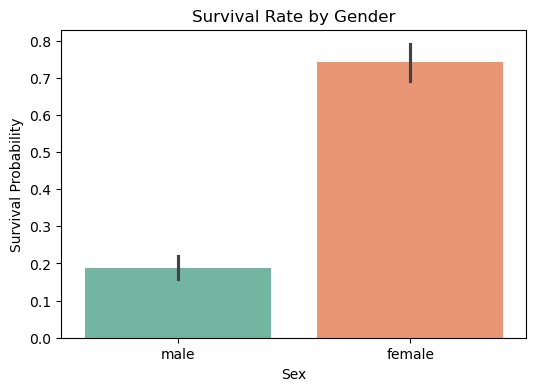

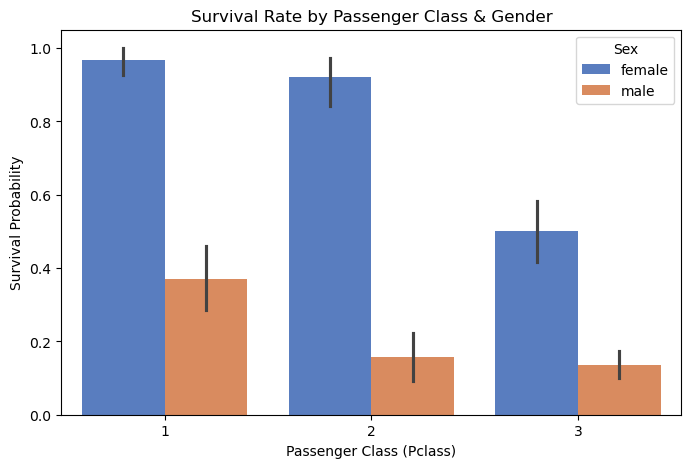

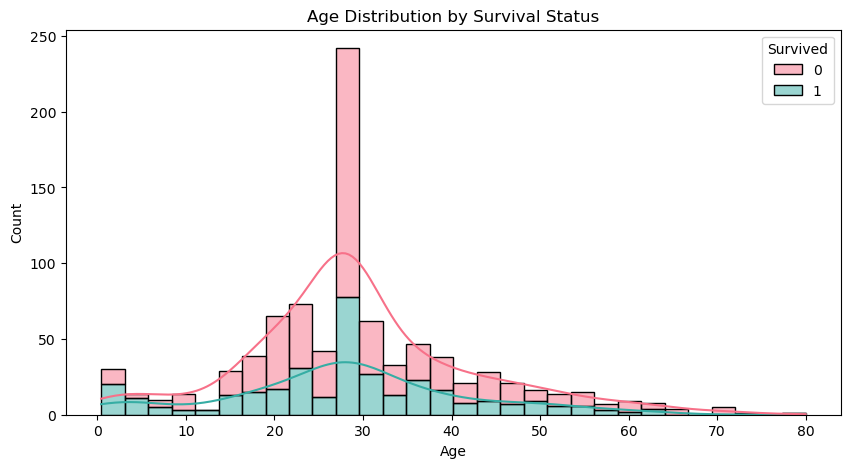

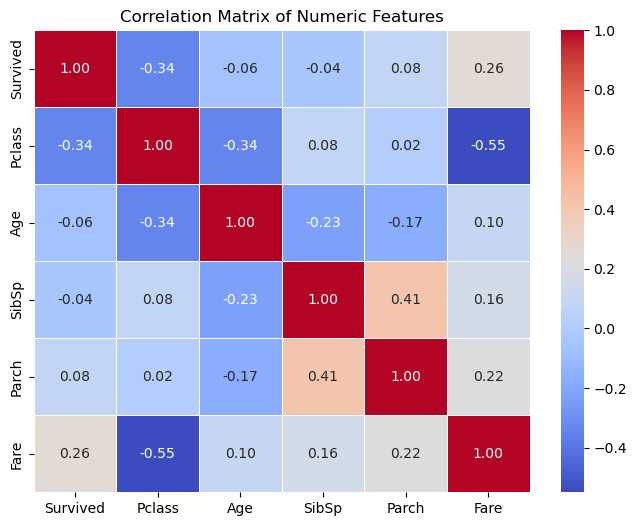

C:\Users\abnvz\AppData\Local\Temp\ipykernel_5600\4180954167.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set3')


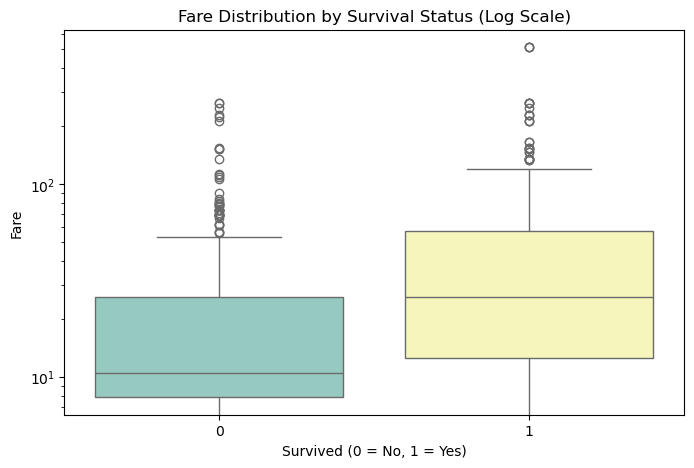

1. Females havd high survival probablity than males i.e 74 and 19 % approximately with a overall 38% surviavl rate

2. 1st Class passengers had a 62.96% survival rate, followed by 47.28% for 2nd Class and 24.23% for 3rd Class

3. Solo travelers and large families (>4 members) faced lower survival odds than small families (1–3 members)

4. Cherbourg showed higher survival (~55.36%) due to a higher proportion of 1st-class passengers


In [37]:
#Task 2 Perfrom eda on a dataset
#Objective - Perfroming eda on a dataset and exploring relationships betwwen variables
#Dataset used is Titanic Dataset from Kaggle

#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading dataset
df = pd.read_csv(r"C:\Users\abnvz\Downloads\Titanic-Dataset.csv")

#data cleaning
print("missing values before preprocessing")
print(df.isnull().sum())

#imputing age with median age
df['Age']=df["Age"].fillna(df['Age'].median())

#imputing age with the most frequent value i.e the mode
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

#dropping 'Cabin' due to high percentage of missing values, and 'PassengerId' / 'Ticket' as they are non-predictive identifiers
df.drop(columns=['Cabin', 'PassengerId', 'Ticket'], inplace=True, errors='ignore')
print("\nmissing values after cleaning")
print(df.isnull().sum())

#visualizations 
#1 gender survival rate
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Probability')
plt.show()

#2 Survival Rate by Passenger Class and Gender
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='muted')
plt.title('Survival Rate by Passenger Class & Gender')
plt.ylabel('Survival Probability')
plt.xlabel('Passenger Class (Pclass)')
plt.show()

#3 survial status age distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette='husl', multiple='stack')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#4 numerical features corelation matrix
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

#fare distribution vs survival impact (box plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set3')
plt.yscale('log')  # Log scale handles skewed fare distributions well
plt.title('Fare Distribution by Survival Status (Log Scale)')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

#interpretations
print("1. Females havd high survival probablity than males i.e 74 and 19 % approximately with a overall 38% surviavl rate")
print("\n2. 1st Class passengers had a 62.96% survival rate, followed by 47.28% for 2nd Class and 24.23% for 3rd Class")
print("\n3. Solo travelers and large families (>4 members) faced lower survival odds than small families (1–3 members)")
print("\n4. Cherbourg showed higher survival (~55.36%) due to a higher proportion of 1st-class passengers")